In [1]:
import pandas as pd
import seaborn as sns

df=pd.read_csv("/content/train.csv")

**1. Understanding the Data**

In [2]:
#Shape, size, data types
print(df.shape)
print(df.dtypes)

(891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [4]:
#first and last rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
#statistical summary
df.describe() #numerical

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.describe(include='object') #categorical

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
#unique values per column
df.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


 pandas uses isnull() and isna() interchangeably — both detect NaN. isna() is preferred in newer pandas versions

**2. Missing Value Analysis**

In [9]:
#detect missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
df.isnull().mean()*100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [13]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

The Age distribution is right-skewed. The mean is pulled by extreme values, so the median is a more representative imputation for skewed data.


In [14]:
df.isnull().mean()*100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,0.000000
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


Cabin - 77% missing is too much to impute. This is almost certainly MNAR — Missing Not At Random. Cabin information is missing because passengers in 3rd class were far less likely to have a recorded cabin.

In [16]:
# Step 1 — extract deck
df['deck'] = df['Cabin'].str[0].fillna('Unknown')

# Step 2 — create has_cabin flag
df['has_cabin'] = df['Cabin'].notnull().astype(int)

# Step 3 — drop raw cabin column
df.drop(columns=['Cabin'], inplace=True)

# Verify
print(df[['deck', 'has_cabin']].value_counts().head(10))

deck     has_cabin
Unknown  0            687
C        1             59
B        1             47
D        1             33
E        1             32
A        1             15
F        1             13
G        1              4
T        1              1
Name: count, dtype: int64


In [17]:
df.shape

(891, 13)

In [18]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [19]:
df.shape

(891, 13)

In [20]:
# Verify no nulls remain
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
deck           0
has_cabin      0
dtype: int64


**3. Univariate Analysis**

studies one variable at a time — its shape, central tendency, spread, and outliers.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

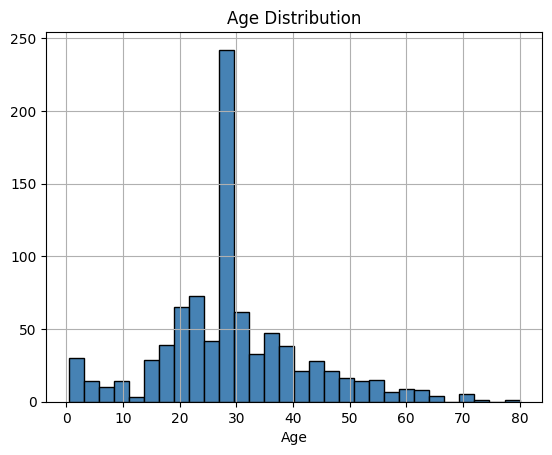

In [23]:
# Histogram of Age
df['Age'].hist(bins=30, color='steelblue', edgecolor='black')
plt.title('Age Distribution'); plt.xlabel('Age'); plt.show()



In [24]:
# ── Skewness & Kurtosis ────────────────────────────────
print('Fare skew:    ', df['Fare'].skew())     # ~4.8 (heavy right skew)
print('Age skew:     ', df['Age'].skew())      # ~0.4 (mild right skew)
print('Age kurtosis: ', df['Age'].kurtosis())

Fare skew:     4.787316519674893
Age skew:      0.5102446555756495
Age kurtosis:  0.9938710163801736


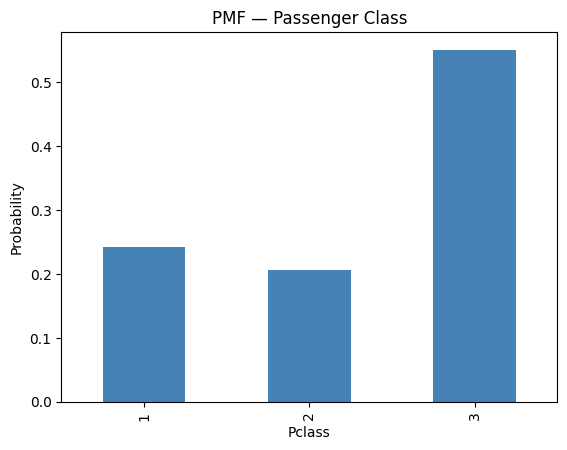

In [26]:
# PMF of Pclass
pmf = df['Pclass'].value_counts(normalize=True).sort_index()
pmf.plot(kind='bar', color='steelblue')
plt.title('PMF — Passenger Class'); plt.ylabel('Probability'); plt.show()



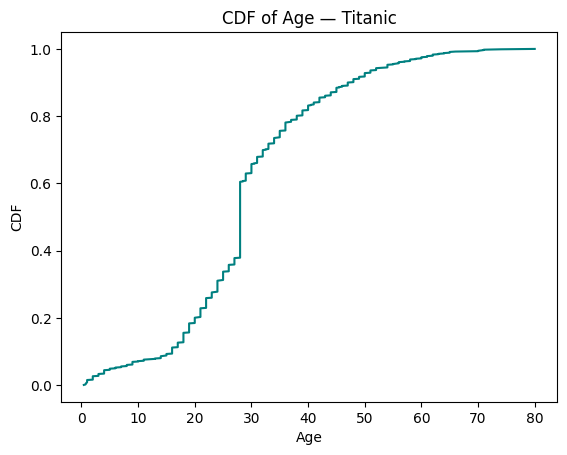

In [27]:
# ── CDF of age ──────────────────────────────────────────
sorted_age = np.sort(df['Age'].dropna())
cdf = np.arange(1, len(sorted_age)+1) / len(sorted_age)
plt.plot(sorted_age, cdf, color='teal')
plt.xlabel('Age'); plt.ylabel('CDF')
plt.title('CDF of Age — Titanic'); plt.show()

~50% of passengers were below age 28 (the median)

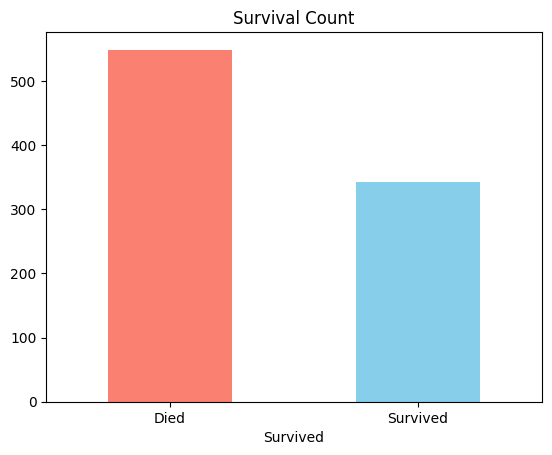

In [28]:
# Survival count
df['Survived'].value_counts().plot(kind='bar', color=['salmon', 'skyblue'])
plt.xticks([0,1], ['Died','Survived'], rotation=0)
plt.title('Survival Count'); plt.show()

Titanic class imbalance: ~62% died (label=0), ~38% survived (label=1). This is a moderately imbalanced dataset — important for model evaluation later.

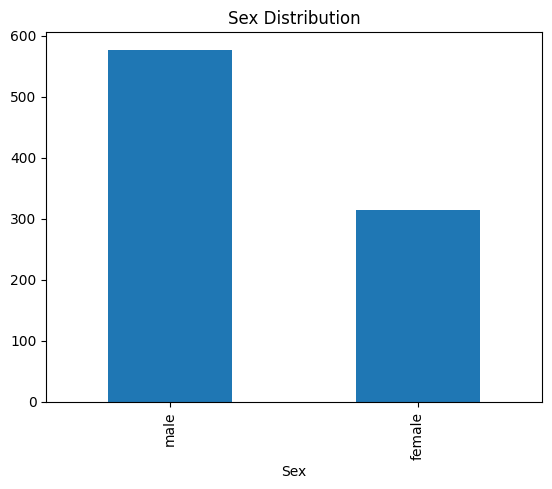

In [29]:
# Sex distribution
df['Sex'].value_counts().plot(kind='bar')
plt.title('Sex Distribution'); plt.show()

**4. Bivariate Analysis**

Bivariate analysis examines the relationship between two variables — especially between each feature and the target (survived).

In [31]:
# Survival rate by Sex
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


massive difference

In [33]:
# Survival rate by Pclass
df.groupby('Pclass')['Survived'].mean()
# 1st: 0.630   2nd: 0.473   3rd: 0.242

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [34]:
# Survival rate by Embarked
df.groupby('Embarked')['Survived'].mean()
# C: 0.554   Q: 0.390   S: 0.337

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.339009


Visualisations — Bar & Box Plots

In [36]:
import seaborn as sns

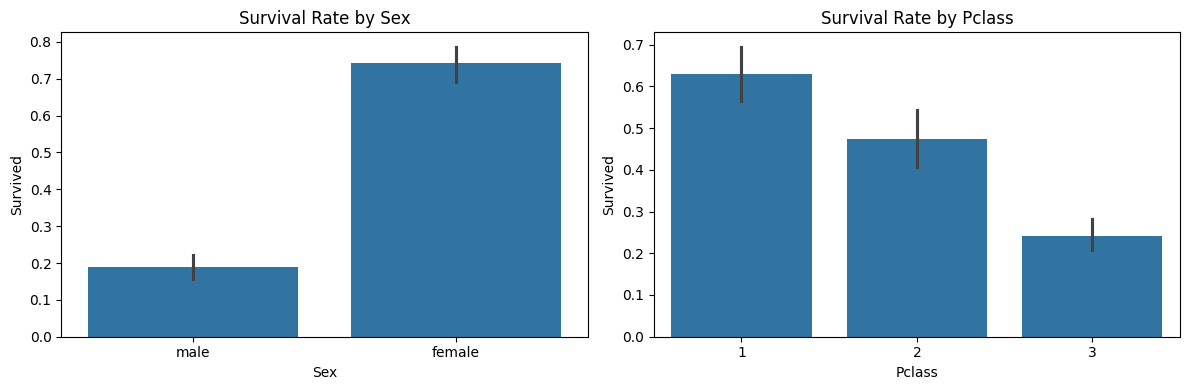

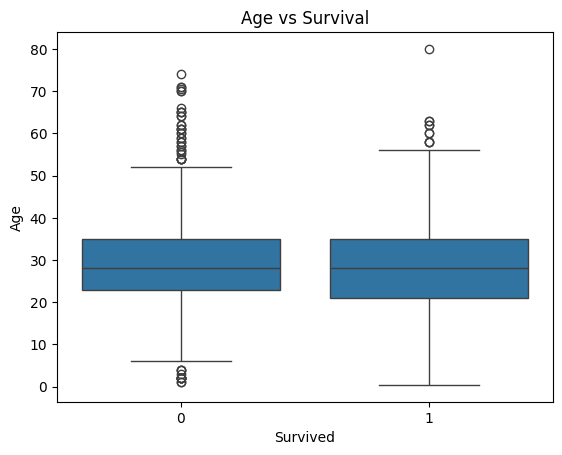

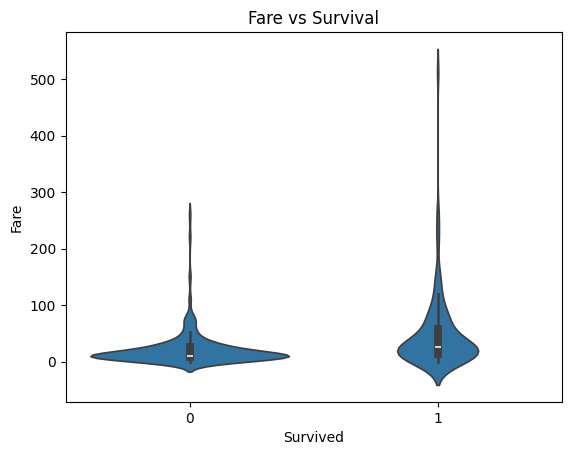

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Survival rate by sex
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0])
axes[0].set_title('Survival Rate by Sex')

# Survival rate by class
sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1])
axes[1].set_title('Survival Rate by Pclass')

plt.tight_layout(); plt.show()

# Age vs Survival (box plot)
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age vs Survival'); plt.show()

# Fare vs Survival (violin plot)
sns.violinplot(x='Survived', y='Fare', data=df)
plt.title('Fare vs Survival'); plt.show()

Instead of just comparing means, Downey recommends quantifying how large the difference actually is. Cohen's d measures the difference in units of standard deviation.

In [39]:
survived_age = df[df['Survived']==1]['Age'].dropna()
died_age     = df[df['Survived']==0]['Age'].dropna()


mean_diff   = survived_age.mean() - died_age.mean()
pooled_std  = np.sqrt((survived_age.std()**2 + died_age.std()**2) / 2)

cohens_d    = mean_diff / pooled_std

print(f'Mean age (survived): {survived_age.mean():.2f}')
print(f'Mean age (died):     {died_age.mean():.2f}')
print(f"Cohen's d:           {cohens_d:.3f}")

Mean age (survived): 28.29
Mean age (died):     30.03
Cohen's d:           -0.132


The negative sign just means the survived group has a lower mean than the died group — survivors were slightly younger. The magnitude is what matters. At d = 0.132, age barely separates survivors from non-survivors. The distributions overlap almost completely.

**5. Multivariate Analysis**

Multivariate analysis examines three or more variables simultaneously, revealing interaction effects that bivariate analysis misses

In [40]:
#Cross-tabulation — Sex × Pclass
pivot = df.groupby(['Sex', 'Pclass'])['Survived'].mean().unstack()
print(pivot)

Pclass         1         2         3
Sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447


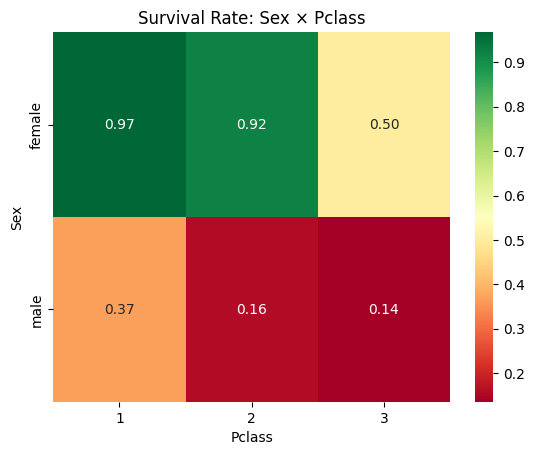

In [41]:
# Visualise as heatmap
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn')
plt.title('Survival Rate: Sex × Pclass'); plt.show()

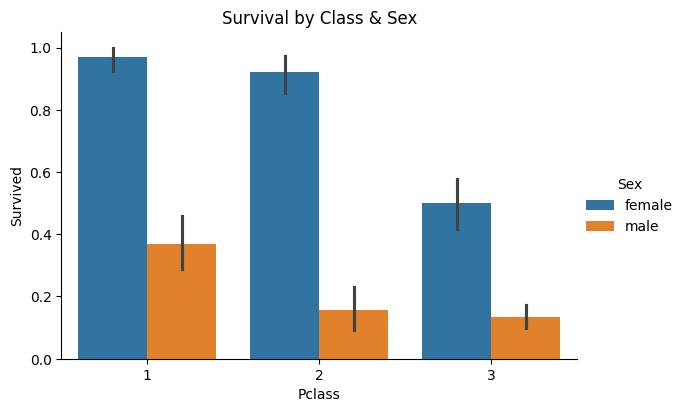

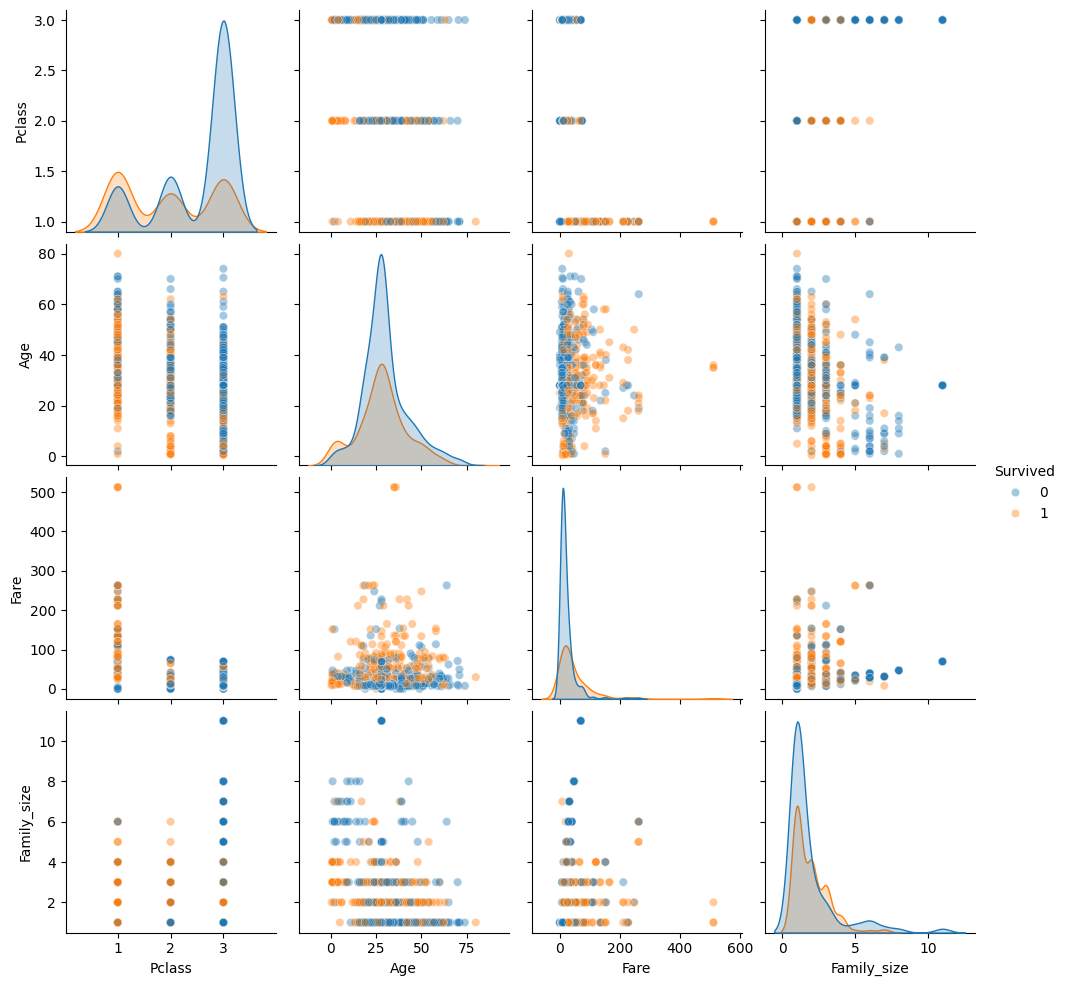

In [43]:
# Faceted bar — Sex, Pclass, Survived together
sns.catplot(x='Pclass', y='Survived', hue='Sex',
            data=df, kind='bar', height=4, aspect=1.5)
plt.title('Survival by Class & Sex'); plt.show()

# Create 'Family_size' column
df['Family_size'] = df['SibSp'] + df['Parch'] + 1

# Pair plot across numerical features
num_cols = ['Survived', 'Pclass', 'Age', 'Fare', 'Family_size']

sns.pairplot(df[num_cols], hue='Survived', plot_kws={'alpha': 0.4})
plt.show()

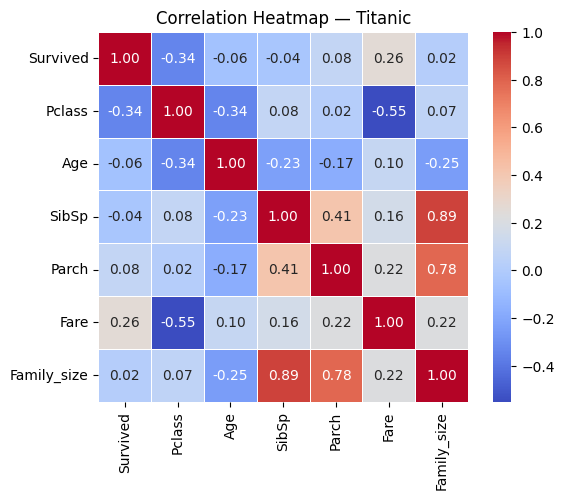

In [44]:
#HeatMap
corr = df[['Survived','Pclass','Age','SibSp',
           'Parch','Fare','Family_size']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Titanic'); plt.show()


 fare and pclass are strongly negatively correlated (r≈-0.55) — expected since higher class = higher ticket. fare and survived are positively correlated (r≈0.26). pclass and survived are negatively correlated (r≈-0.34)

In [46]:
#Is Alone?
df['is_alone'] = (df['Family_size'] == 1).astype(int)

# log-transform Fare (reduce right skew)
df['log_fare'] = np.log1p(df['Fare'])   # log1p handles 0 safely

In [47]:
# Compare skewness before/after
print('Original fare skew:', df['Fare'].skew())
print('Log fare skew:     ', df['log_fare'].skew())


Original fare skew: 4.787316519674893
Log fare skew:      0.3949280095189306


In [48]:
# Age Bins
df['age_group'] = pd.cut(df['Age'],
                         bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child','Teen','Adult','Middle','Senior'])

# Survival rate by age group
df.groupby('age_group')['Survived'].mean()

/tmp/ipykernel_20999/1831376631.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['Survived'].mean()


,Survived
age_group,
Child,0.579710
Teen,0.428571
Adult,0.353271
Middle,0.400000
Senior,0.227273


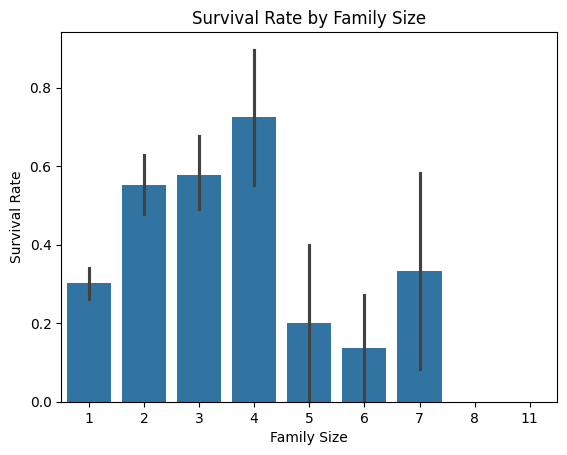

In [50]:
sns.barplot(x='Family_size', y='Survived', data=df)
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size'); plt.ylabel('Survival Rate')
plt.show()

# Pattern: solo travellers and very large families survive less.
# Family sizes 2-4 have the highest survival rates.


**7. Outlier Detection**

Outliers are extreme values that may represent errors, anomalies, or genuinely rare cases

Number of fare outliers: 116


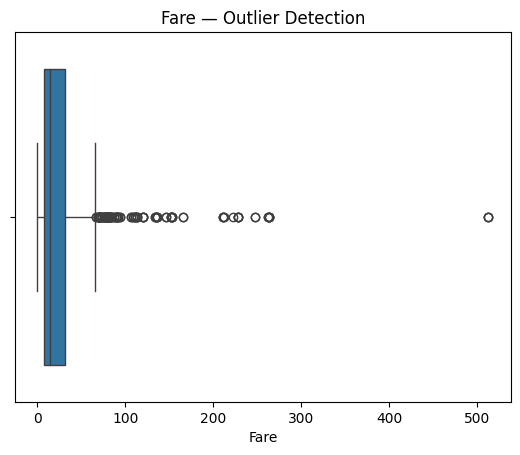

In [51]:
# IQR = Q3 - Q1; outliers lie beyond 1.5×IQR
Q1  = df['Fare'].quantile(0.25)
Q3  = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]
print(f'Number of fare outliers: {len(outliers)}')

# Visualise
sns.boxplot(x=df['Fare'])
plt.title('Fare — Outlier Detection'); plt.show()

In [52]:
from scipy import stats

z_scores = np.abs(stats.zscore(df['Age'].dropna()))
# Flag rows with |z| > 3 as outliers
age_outliers = df[z_scores > 3]
print(f'Age outliers (z>3): {len(age_outliers)}')



Age outliers (z>3): 7


If outlier is a genuine data error → remove. If it is a real but rare observation → keep, but consider log-transforming the feature. Capping (Winsorization) is another option — replace values beyond the 1st/99th percentile.